# Solcellsbatteri – hur stort batteri är bäst?

**Fråga:** Om vi skaffar ett batteri till solcellsanläggningen (Fronius Symo GEN24 10.0, 11,89 kWp) – vilken storlek ger bästa avvägningen mellan kostnad och besparing?

**Metod:** Timvis simulering mot **verklig mätdata 2024-01-01 → 2026-06-12** (2,5 år) från InfluxDB:

| Data | Sensor |
|---|---|
| Nätutbyte (import/export, W) | `smart_meter_ts_65a_3_aktiv_effekt` (negativ = export) |
| Solproduktion (W) | `solarnet_effekt_solceller` |
| Spotpris SE3 inkl moms | `nordpool_kwh_se3_sek` (2024–2025) + `nordpool_kwh_se3_sek_3_10_025` (2026–) |

Batteriet simuleras timme för timme: ladda från solöverskott som annars exporteras, ladda ur mot import. Besparingen värderas med **2026 års regler** (60-öringen är borttagen, vilket gör egenanvändning klart mer värd än försäljning).

Effektavgiften (snitt av månadens 5 högsta timtoppar) räknas om med och utan batteri, så toppkapnings-värdet ingår.


## 1. Parametrar och antaganden (verifierade 2026)

| Parameter | Värde | Källa |
|---|---|---|
| Energiskatt 2026 | 45,0 öre/kWh inkl moms (sänkt från 54,9) | Skatteverket / Energimarknadsbyrån |
| Elöverföring Tekniska verken (effekttariff villa) | 14,9 öre/kWh inkl moms | tekniskaverken.se priser elnät 2026 |
| Effektavgift 2026 | **23 kr/kW sommar (apr–okt) / 45 kr/kW vinter** (höjt från 22/43) | tekniskaverken.se |
| Elhandelspåslag (Skellefteå Kraft) | 6,6 öre/kWh | egen `template_sensors.yaml` |
| Såld el | spot (exkl moms) + 2 öre påslag + nätnytta 5,1/7,2 öre | tekniskaverken.se ersättning 2026 |
| 60-öringen (skattereduktion såld el) | **Slopad från 2026-01-01** | riksdagsbeslut maj 2025 |
| Verkningsgrad batteri | 90 % round-trip (95 % per riktning), DC-kopplad BYD + GEN24 | Fronius/BYD datablad |
| Batterikostnad installerat | ~6 500 kr/kWh före avdrag (känslighet: 4 000–7 500) | Hemsol/Laddgruppen 2025/26 |
| Grön teknik-avdrag batteri | 48,5 % av fakturan (50 % på 97 % schablon), OK även med arbitrage/stödtjänster | Skatteverket |
| Batteristorlekar | BYD Battery-Box Premium HVS 5.1–12.8 / HVM 16.6–22.1 (kompatibla med GEN24) | Fronius kompatibilitetslista |


In [1]:
import pandas as pd, numpy as np, urllib.request, urllib.parse, json, os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

# Prismodell 2026 (kr/kWh)
MARKUP      = 0.066   # elhandelspåslag inkl elcert
ENERGISKATT = 0.450   # inkl moms
NET_FEE     = 0.149   # elöverföring inkl moms
SELL_BONUS  = 0.02    # Skellefteå kraft
EFF         = 0.95    # per riktning => ~90% round-trip
EFFEKT_SOMMAR, EFFEKT_VINTER = 23, 45   # kr/kW och månad

# Batterikostnad
PRIS_PER_KWH   = 6500   # installerat, före avdrag
GRON_TEKNIK    = 0.485  # andel avdrag
SIZES = [5.1, 7.7, 10.2, 12.8, 16.6, 19.3, 22.1]  # BYD HVS/HVM användbar kapacitet

## 2. Hämta timdata från InfluxDB

Timmedel hämtas per halvår (för att hålla oss under radgränsen) och cachas i `battery_df.pkl`.


In [2]:
BASE = "http://192.168.1.62:8086/query?db=homeassistant&"
# Pickle anvands enbart som lokal cache som denna notebook sjalv skapar - ingen extern data.
CACHE = '/config/notebooks/battery_df.pkl'

def influx_hourly(measurement, entity, start, end):
    q = (f'SELECT mean(value) FROM "{measurement}" WHERE entity_id=\'{entity}\' '
         f"AND time >= '{start}' AND time < '{end}' GROUP BY time(1h)")
    d = json.loads(urllib.request.urlopen(BASE + urllib.parse.urlencode({'q': q}), timeout=120).read())
    res = d['results'][0]
    if 'series' not in res:
        return pd.Series(dtype=float)
    return pd.Series({pd.Timestamp(t): v for t, v in res['series'][0]['values']})

def fetch_full(measurement, entity, start='2024-01-01', end='2026-06-12'):
    rng = pd.date_range(start, end, freq='180D').tolist() + [pd.Timestamp(end)]
    chunks = [influx_hourly(measurement, entity, a.strftime('%Y-%m-%dT00:00:00Z'),
                            b.strftime('%Y-%m-%dT00:00:00Z')) for a, b in zip(rng[:-1], rng[1:])]
    s = pd.concat([c for c in chunks if len(c)])
    return s[~s.index.duplicated()]

if os.path.exists(CACHE):
    df = pd.read_pickle(CACHE)
else:
    grid = fetch_full('W', 'smart_meter_ts_65a_3_aktiv_effekt')
    pv = fetch_full('W', 'solarnet_effekt_solceller')
    price = pd.concat([fetch_full('SEK/kWh', 'nordpool_kwh_se3_sek'),
                       fetch_full('SEK/kWh', 'nordpool_kwh_se3_sek_3_10_025', start='2026-01-07')]).sort_index()
    price = price[~price.index.duplicated(keep='last')]
    df = pd.DataFrame({'grid_w': grid, 'pv_w': pv})
    df['price_ivat'] = price.reindex(df.index)
    df.to_pickle(CACHE)

print(f"{len(df)} timmar, {df.index[0]:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d}")

21432 timmar, 2024-01-01 -> 2026-06-11


## 3. Datatvätt

- Korta mätluckor (≤3 h) interpoleras, långa block (några veckors HA-avbrott) utesluts – årsvärden skalas med täckningsgraden.
- Prisluckan 2025-12-17 → 2026-01-07 (byte av Nordpool-sensor) fylls med timprofil från omgivande vintermånader.
- PV-sensorn rapporterar inget nattetid → NaN ⇒ 0.


In [3]:
df['grid_w'] = df.grid_w.interpolate(limit=3)
df['pv_w'] = df.pv_w.fillna(0)
df['price_ivat'] = df.price_ivat.interpolate(limit=6)
mask = df.price_ivat.isna()
ref = df.loc['2025-11-15':'2026-02-15']
profil = ref.groupby(ref.index.hour).price_ivat.mean()
df.loc[mask, 'price_ivat'] = df.index[mask].hour.map(profil)

valid = df.grid_w.notna()
print(f"Giltiga timmar: {valid.sum()} av {len(df)} ({valid.mean():.0%})")
print("Täckning per år:")
print(valid.groupby(df.index.year).mean().round(3).to_string())

d = df[valid].copy()
d['imp'] = d.grid_w.clip(lower=0) / 1000.0      # kWh importerad per timme
d['exp'] = (-d.grid_w).clip(lower=0) / 1000.0   # kWh exporterad per timme
YRS = len(d) / 8766

Giltiga timmar: 19628 av 21432 (92%)
Täckning per år:
2024    0.927
2025    0.910
2026    0.903


## 4. Hur ser över-/underskottet ut?

Batteriets värde styrs av hur mycket sol som idag **exporteras** (billigt sålt) och samtidigt hur mycket som **importeras** (dyrt köpt) samma dygn.


                          värde
Import (kWh/år)          6680.0
Export (kWh/år)          8852.0
Solproduktion (kWh/år)  12809.0


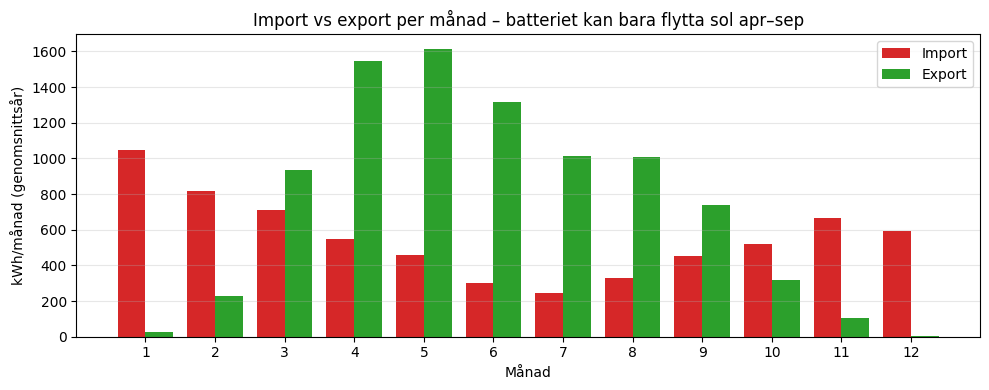


Dagligt exportöverskott (kWh/dag) per månad:
     25%  median   75%
1    0.0     0.0   0.0
2    0.0     1.4  11.4
3    6.1    20.8  37.0
4   20.7    44.0  58.7
5   34.9    51.0  64.7
6   29.5    45.9  64.2
7   28.5    45.5  61.6
8   25.5    45.7  52.5
9   16.3    29.3  39.8
10   1.1     8.7  19.2
11   0.0     0.8   7.8
12   0.0     0.0   0.0


In [4]:
arlig = pd.DataFrame({
    'Import (kWh/år)': [d.imp.sum()/YRS],
    'Export (kWh/år)': [d.exp.sum()/YRS],
    'Solproduktion (kWh/år)': [d.pv_w.sum()/1000/YRS],
}).round(0).T.rename(columns={0:'värde'})
print(arlig.to_string())

man = d.groupby(d.index.month).agg(imp=('imp','sum'), exp=('exp','sum')) / YRS
fig, ax = plt.subplots(figsize=(10,4))
x = man.index
ax.bar(x-0.2, man.imp, 0.4, label='Import', color='tab:red')
ax.bar(x+0.2, man.exp, 0.4, label='Export', color='tab:green')
ax.set_xticks(x); ax.set_xlabel('Månad'); ax.set_ylabel('kWh/månad (genomsnittsår)')
ax.set_title('Import vs export per månad – batteriet kan bara flytta sol apr–sep')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Dagligt solöverskott (= max batteriet kan ladda från sol) per månad
dag = d.groupby(d.index.date).agg(exp=('exp','sum'))
dag.index = pd.to_datetime(dag.index)
kvant = dag.groupby(dag.index.month).exp.quantile([0.25, 0.5, 0.75]).unstack()
kvant.columns = ['25%', 'median', '75%']
print('\nDagligt exportöverskott (kWh/dag) per månad:')
print(kvant.round(1).to_string())

## 5. Prismodell – vad är en flyttad kWh värd?

- **Undviken import:** spot inkl moms + påslag 6,6 öre + energiskatt 45 öre + överföring 14,9 öre
- **Förlorad export:** spot exkl moms + 2 öre + nätnytta (5,1 öre lågpris / 7,2 öre vardagar 06–22 nov–mar)

Skillnaden (spread) är vad batteriet tjänar per kWh solflytt – *före* verkningsgradsförluster.


In [5]:
vinter = d.index.month.isin([1, 2, 3, 11, 12])
hogpris = vinter & (d.index.dayofweek < 5) & (d.index.hour >= 6) & (d.index.hour < 22)
natnytta = np.where(hogpris, 0.072, 0.051)

d['buy']  = d.price_ivat + MARKUP + ENERGISKATT + NET_FEE
d['sell'] = d.price_ivat / 1.25 + SELL_BONUS + natnytta

print(f"Medelköppris:  {d.buy.mean():.2f} kr/kWh")
print(f"Medelsäljpris: {d.sell.mean():.2f} kr/kWh")
print(f"Medelspread:   {(d.buy - d.sell).mean():.2f} kr/kWh (varav fasta komponenter ~0.60 + momsdelen av spot)")

Medelköppris:  1.34 kr/kWh
Medelsäljpris: 0.62 kr/kWh
Medelspread:   0.72 kr/kWh (varav fasta komponenter ~0.60 + momsdelen av spot)


## 6. Batterisimulering

Timme för timme, girig strategi:
1. **Ladda** från exportöverskott (det som annars säljs) upp till effektgräns och ledig kapacitet.
2. **Ladda ur** mot import (det som annars köps).

Valbart tillägg: **nattarbitrage på vintern** – ladda från nätet de billigaste timmarna när dagens spread är stor och ingen sol väntas. *(Spoiler: med effekttariff straffar det sig – nattladdningen höjer månadens topp-5-snitt.)*

Effektgräns: `min(kapacitet, 8) kW` (BYD klarar ~1C, GEN24 10.0 max ~8–10 kW batterieffekt).


In [6]:
def simulate(cap, p_kw=None, arbitrage=False, arb_spread=0.50, arb_cap_kw=3.0):
    if p_kw is None:
        p_kw = min(cap, 8.0)
    imp, exp = d.imp.values, d.exp.values
    buy, sell, idx = d.buy.values, d.sell.values, d.index
    n, soc = len(d), 0.0
    dis, chg_s, chg_g = np.zeros(n), np.zeros(n), np.zeros(n)

    arb_c = set()
    if arbitrage:
        for day, g in d.groupby(d.index.date):
            if g.exp.sum() > 0.3 * cap:      # soldag - batteriet är upptaget
                continue
            nh = max(1, int(np.ceil(cap / arb_cap_kw)))
            cheap, expens = g.buy.nsmallest(nh), g.buy.nlargest(6)
            if expens.mean() - cheap.mean() / EFF**2 < arb_spread:
                continue
            arb_c.update(cheap.index)

    for i in range(n):
        c = min(exp[i], p_kw, (cap - soc) / EFF)          # ladda från sol
        if c > 0:
            soc += c * EFF; chg_s[i] = c
        if idx[i] in arb_c:                                # billig natt-timme: ladda fran nat
            g2 = min(arb_cap_kw, (cap - soc) / EFF)
            if g2 > 0:
                soc += g2 * EFF; chg_g[i] = g2
        else:                                              # ladda ur mot import
            dd = min(imp[i], p_kw, soc * EFF)
            if dd > 0:
                soc -= dd / EFF; dis[i] = dd

    new_imp = imp - dis + chg_g
    energi = (dis * buy).sum() - (chg_s * sell).sum() - (chg_g * buy).sum()

    # Effektavgift: snitt av manadens 5 hogsta timtoppar, fore/efter
    r = pd.DataFrame({'i0': imp, 'i1': new_imp}, index=idx)
    m = r.groupby(pd.Grouper(freq='MS')).agg(p0=('i0', lambda x: x.nlargest(5).mean()),
                                             p1=('i1', lambda x: x.nlargest(5).mean()))
    rate = np.where((m.index.month >= 4) & (m.index.month <= 10), EFFEKT_SOMMAR, EFFEKT_VINTER)
    effekt = ((m.p0 - m.p1) * rate).sum()

    return dict(kapacitet=cap, energi_kr_ar=energi/YRS, effekt_kr_ar=effekt/YRS,
                totalt_kr_ar=(energi+effekt)/YRS, cykler_ar=dis.sum()/cap/YRS,
                solflytt_kwh_ar=chg_s.sum()/YRS, nattladd_kwh_ar=chg_g.sum()/YRS)

## 7. Resultat per batteristorlek


In [7]:
r1 = pd.DataFrame([simulate(c) for c in SIZES]).set_index('kapacitet').round(0)
print('=== Strategi A: enbart solflytt ===')
print(r1.to_string())

r2 = pd.DataFrame([simulate(c, arbitrage=True) for c in SIZES]).set_index('kapacitet').round(0)
print('\n=== Strategi B: solflytt + nattarbitrage (vinter) ===')
print(r2.to_string())

print('\nNotera: arbitragets energivinst äts upp av höjd effektavgift (negativa effekt-kr).')
print('Med effekttariff ska nattladdning undvikas, eller effektbegränsas hårt.')

=== Strategi A: enbart solflytt ===
           energi_kr_ar  effekt_kr_ar  totalt_kr_ar  cykler_ar  solflytt_kwh_ar  nattladd_kwh_ar
kapacitet                                                                                       
5.1               993.0          90.0        1083.0      246.0           1390.0              0.0
7.7              1368.0         106.0        1474.0      236.0           2016.0              0.0
10.2             1682.0         127.0        1809.0      227.0           2573.0              0.0
12.8             1934.0         150.0        2084.0      211.0           2996.0              0.0
16.6             2136.0         188.0        2325.0      179.0           3305.0              0.0
19.3             2218.0         205.0        2423.0      159.0           3410.0              0.0
22.1             2273.0         218.0        2491.0      142.0           3484.0              0.0



=== Strategi B: solflytt + nattarbitrage (vinter) ===
           energi_kr_ar  effekt_kr_ar  totalt_kr_ar  cykler_ar  solflytt_kwh_ar  nattladd_kwh_ar
kapacitet                                                                                       
5.1              1040.0        -305.0         736.0      293.0           1389.0            264.0
7.7              1516.0        -393.0        1123.0      286.0           2015.0            426.0
10.2             1919.0        -425.0        1495.0      276.0           2567.0            551.0
12.8             2307.0        -425.0        1883.0      260.0           2989.0            703.0
16.6             2641.0        -404.0        2237.0      227.0           3295.0            878.0
19.3             2781.0        -408.0        2373.0      206.0           3390.0           1023.0
22.1             2808.0        -407.0        2401.0      186.0           3433.0           1141.0

Notera: arbitragets energivinst äts upp av höjd effektavgift (negativa 

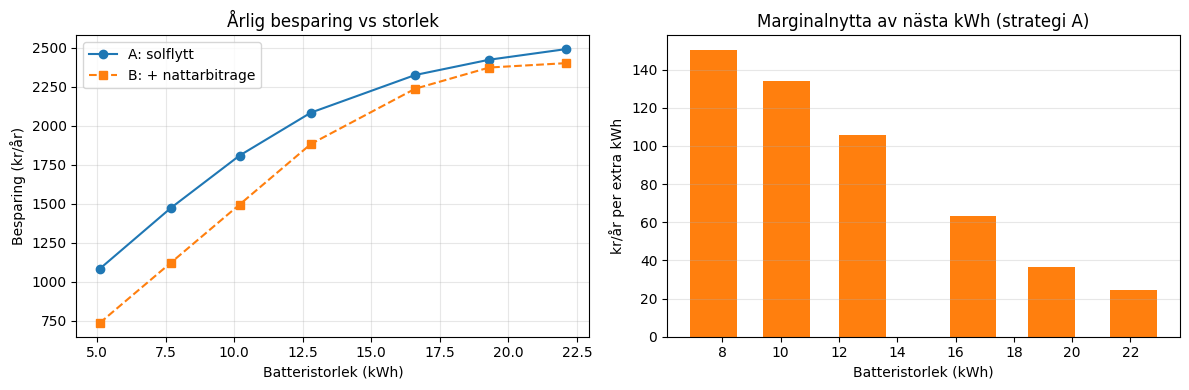

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(r1.index, r1.totalt_kr_ar, 'o-', label='A: solflytt')
ax.plot(r2.index, r2.totalt_kr_ar, 's--', label='B: + nattarbitrage')
ax.set_xlabel('Batteristorlek (kWh)'); ax.set_ylabel('Besparing (kr/år)')
ax.set_title('Årlig besparing vs storlek'); ax.legend(); ax.grid(alpha=0.3)

marg = r1.totalt_kr_ar.diff() / r1.index.to_series().diff()
ax = axes[1]
ax.bar(r1.index[1:], marg.iloc[1:], width=1.6, color='tab:orange')
ax.set_xlabel('Batteristorlek (kWh)'); ax.set_ylabel('kr/år per extra kWh')
ax.set_title('Marginalnytta av nästa kWh (strategi A)'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Payback och känslighet

Kostnad = storlek × pris/kWh × (1 − 48,5 % grön teknik). Tre prisscenarier, samt effekten av stödtjänster (CheckWatt m.fl. – volatilt, ~300–1000 kr/kW/år 2025/26, räknat på 5 kW här).


In [9]:
rows = []
for c in SIZES:
    bes = r1.loc[c, 'totalt_kr_ar']
    for pris in [7500, 6500, 4000]:
        kostnad = c * pris * (1 - GRON_TEKNIK)
        rows.append(dict(kapacitet=c, prisniva=pris, kostnad_kr=round(kostnad),
                         besparing_kr_ar=bes, payback_ar=round(kostnad / bes, 1)))
pb = pd.DataFrame(rows).pivot(index='kapacitet', columns='prisniva', values='payback_ar')
pb.columns = [f'{p} kr/kWh' for p in pb.columns]
print('Payback (år) utan stödtjänster, efter grön teknik-avdrag:')
print(pb.to_string())

STODTJANST = 500 * 5   # kr/år, 500 kr/kW × 5 kW - osäkert!
pb2 = pd.DataFrame(rows)
pb2['payback_med_stod'] = (pb2.kostnad_kr / (pb2.besparing_kr_ar + STODTJANST)).round(1)
print(f'\nMed stödtjänster +{STODTJANST} kr/år (500 kr/kW × 5 kW – mycket osäkert):')
print(pb2.pivot(index='kapacitet', columns='prisniva', values='payback_med_stod').to_string())

Payback (år) utan stödtjänster, efter grön teknik-avdrag:
           4000 kr/kWh  6500 kr/kWh  7500 kr/kWh
kapacitet                                       
5.1                9.7         15.8         18.2
7.7               10.8         17.5         20.2
10.2              11.6         18.9         21.8
12.8              12.7         20.6         23.7
16.6              14.7         23.9         27.6
19.3              16.4         26.7         30.8
22.1              18.3         29.7         34.3

Med stödtjänster +2500 kr/år (500 kr/kW × 5 kW – mycket osäkert):
prisniva   4000  6500  7500
kapacitet                  
5.1         2.9   4.8   5.5
7.7         4.0   6.5   7.5
10.2        4.9   7.9   9.1
12.8        5.8   9.3  10.8
16.6        7.1  11.5  13.3
19.3        8.1  13.1  15.1
22.1        9.1  14.8  17.1


## 9. Slutsats

**Bästa avvägning: ~10 kWh (BYD HVS 10.2), möjligen 12.8.**

- Marginalnyttan är ~130–150 kr/kWh/år upp till ~10 kWh, faller till ~105 vid 12.8 och **kollapsar därefter** (~60 → 25 kr/kWh/år). Över 13 kWh betalar de extra kilowattimmarna aldrig för sig – huset hinner helt enkelt inte använda mer flyttad sol per dygn (median-överskottet apr–aug är ~25–35 kWh/dag men nattförbrukningen är begränsad).
- En 10,2 kWh täcker nattförbrukningen de flesta sol-dygn och gör ~230 cykler/år.
- **Ren ekonomi är fortfarande svag**: ~19 års payback vid dagens premiumpris (6 500 kr/kWh före avdrag) mot 10 års garanti. Vid budgetpris ~4 000 kr/kWh: ~12 år. Med stödtjänster (om nivåerna håller): ~8–10 år – då börjar det gå ihop.
- **Nattarbitrage lönar sig inte** med Tekniska verkens effekttariff – höjda vintertoppar (45 kr/kW) äter upp spotvinsten. Kräver i så fall toppmedveten styrning.
- 60-öringens avskaffande 2026 är hela anledningen att detta alls är nära lönsamt – varje såld kWh tappade ~0,60 kr i värde, vilket gjorde egenanvändning ~dubbelt så värdefull som försäljning.

**Rekommendation:** Vänta tills ett komplett BYD HVS 10.2-paket (DC-kopplat till befintlig GEN24) går att få för ≤45–50 tkr före avdrag (~25 tkr efter), eller kombinera med stödtjänstavtal. Större än 12,8 kWh är fel oavsett pris.
